In [5]:
import sys
sys.path.append("../src")
from data_loader import load_all
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

drivers, vehicles, trips, telemetry = load_all()
for name, df in [("drivers", drivers), ("vehicles", vehicles), ("trips", trips), ("telemetry", telemetry)]:
    print(name, df.shape)

drivers (30, 8)
vehicles (30, 8)
trips (450, 14)
telemetry (12987, 13)


In [6]:
trips.info()
telemetry.info()

<class 'pandas.DataFrame'>
RangeIndex: 450 entries, 0 to 449
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Trip_ID          450 non-null    str    
 1   Driver_ID        450 non-null    str    
 2   Vehicle_ID       450 non-null    str    
 3   Trip_Date        450 non-null    str    
 4   Start_Time       450 non-null    str    
 5   End_Time         450 non-null    str    
 6   Duration_Min     450 non-null    int64  
 7   Distance_KM      450 non-null    float64
 8   Avg_Speed_kmph   450 non-null    float64
 9   Max_Speed_kmph   450 non-null    float64
 10  Start_Latitude   450 non-null    float64
 11  Start_Longitude  450 non-null    float64
 12  End_Latitude     450 non-null    float64
 13  End_Longitude    450 non-null    float64
dtypes: float64(7), int64(1), str(6)
memory usage: 49.3 KB
<class 'pandas.DataFrame'>
RangeIndex: 12987 entries, 0 to 12986
Data columns (total 13 columns):
 #   Column  

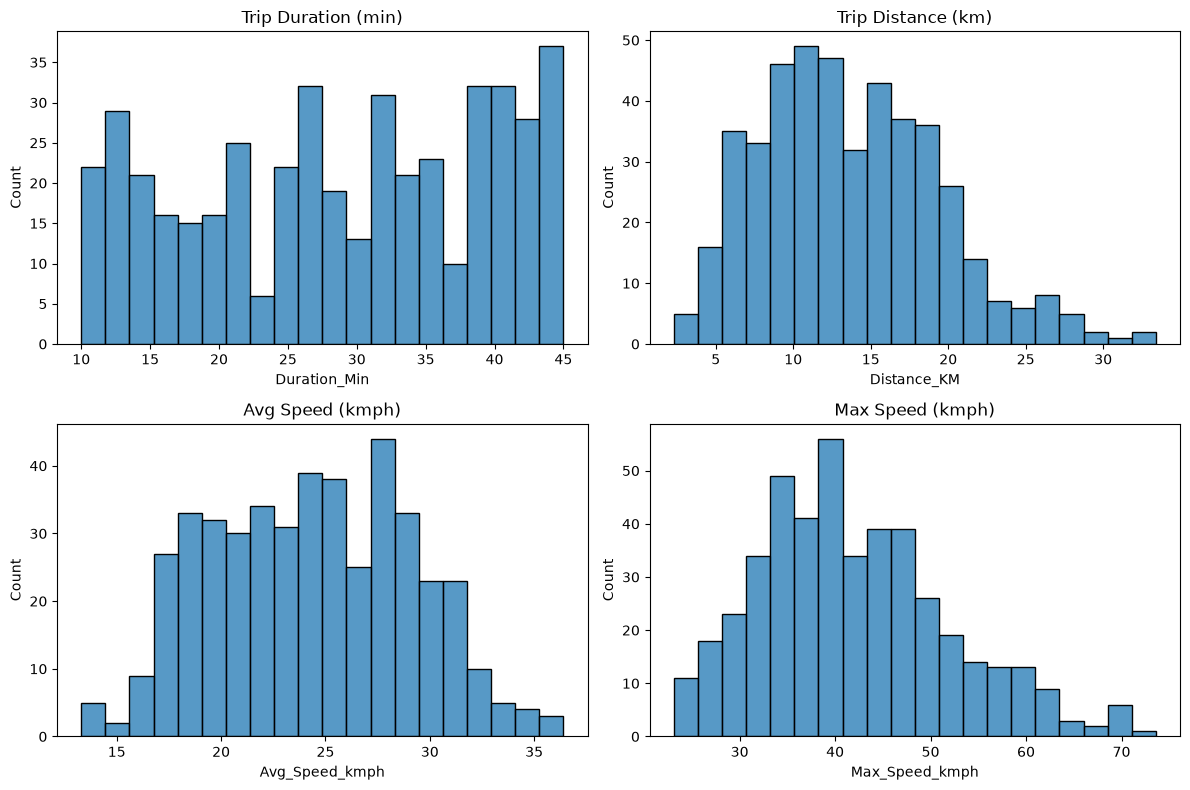

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.histplot(trips["Duration_Min"], bins=20, ax=axes[0, 0]).set_title(
    "Trip Duration (min)"
)
sns.histplot(trips["Distance_KM"], bins=20, ax=axes[0, 1]).set_title(
    "Trip Distance (km)"
)
sns.histplot(trips["Avg_Speed_kmph"], bins=20, ax=axes[1, 0]).set_title(
    "Avg Speed (kmph)"
)
sns.histplot(trips["Max_Speed_kmph"], bins=20, ax=axes[1, 1]).set_title(
    "Max Speed (kmph)"
)
plt.tight_layout()
plt.show()

Description of the plots and details incurred from the them:
1. Duration is fairly evenly spread across 10-45 min rather than normally distributed — multiple local peaks (12-13, 26-27, 40-41, 44-45 min) with no single dominant mode. The dips at 23-24 min and 37 min are likely just binning/sampling noise rather than a meaningful pattern.
Since duration doesn't cluster around one typical trip length, any per-trip feature (like event counts) should probably be normalized by duration (e.g. harsh-brake events per minute) rather than used as a raw count, or short trips will look artificially 'safer' just by having less time to accumulate events.

2. The Trip distance data is right skewed with the peak happening at 10km rides which has a count of 50, we can also observe taht after the 20km mark the count of rides is decreasing , with the extreme rides that are 30km or more having lesser than 5 rides. On the left side the case is not the same as only rides below 5km have a low count which is lesser than 5.
The right skew means a handful of longer trips (30km+) will dominate any distance-weighted average if we're not careful — e.g. total distance per driver could be inflated by one or two long trips rather than reflecting typical driving. Worth checking median alongside mean at the driver level.

3. The avg speed data is approximately normal with a pronounced peak around 27-28 kmph but the drop/rise on the left hand side can be considered sharp as the data jumps straight from less than 10 at the 16-17kmph mark to greater than 25 count at 17-18kmph, the same can be noticed on the right side where speeds greater than 32-33 kmph have a count of 10 or less.
The sharp jump around 17-18 kmph could just be how the data was generated, but it's worth checking whether it maps to something real like Home_Hub/route type (city vs highway) — if it does, avg speed alone might partly reflect route choice rather than driving style, which matters for how fairly a 'risk score' attributes blame to the driver.

4. Finally from the max speed data we can see that it is right skewed with speeds peaking at 40kmph that has more than 50 counts, after which it gradually decreases with high speeds like 60-70kmph having less trhan 10 counts.
Since most trips top out around 35-45 kmph but a smaller set reach 60-70+, a fixed threshold like 'max speed > 60 = risky' would only flag a small tail. Better to define the speeding feature as a percentile-based or relative-to-trip-average threshold (e.g. max speed significantly above that trip's own avg speed) rather than one global cutoff — that also normalizes for the route variation flagged in point 3.

NOTE: from plot 3 we have a very methodological question: "is speed a driver behavior signal or a route signal?", tackle it later.

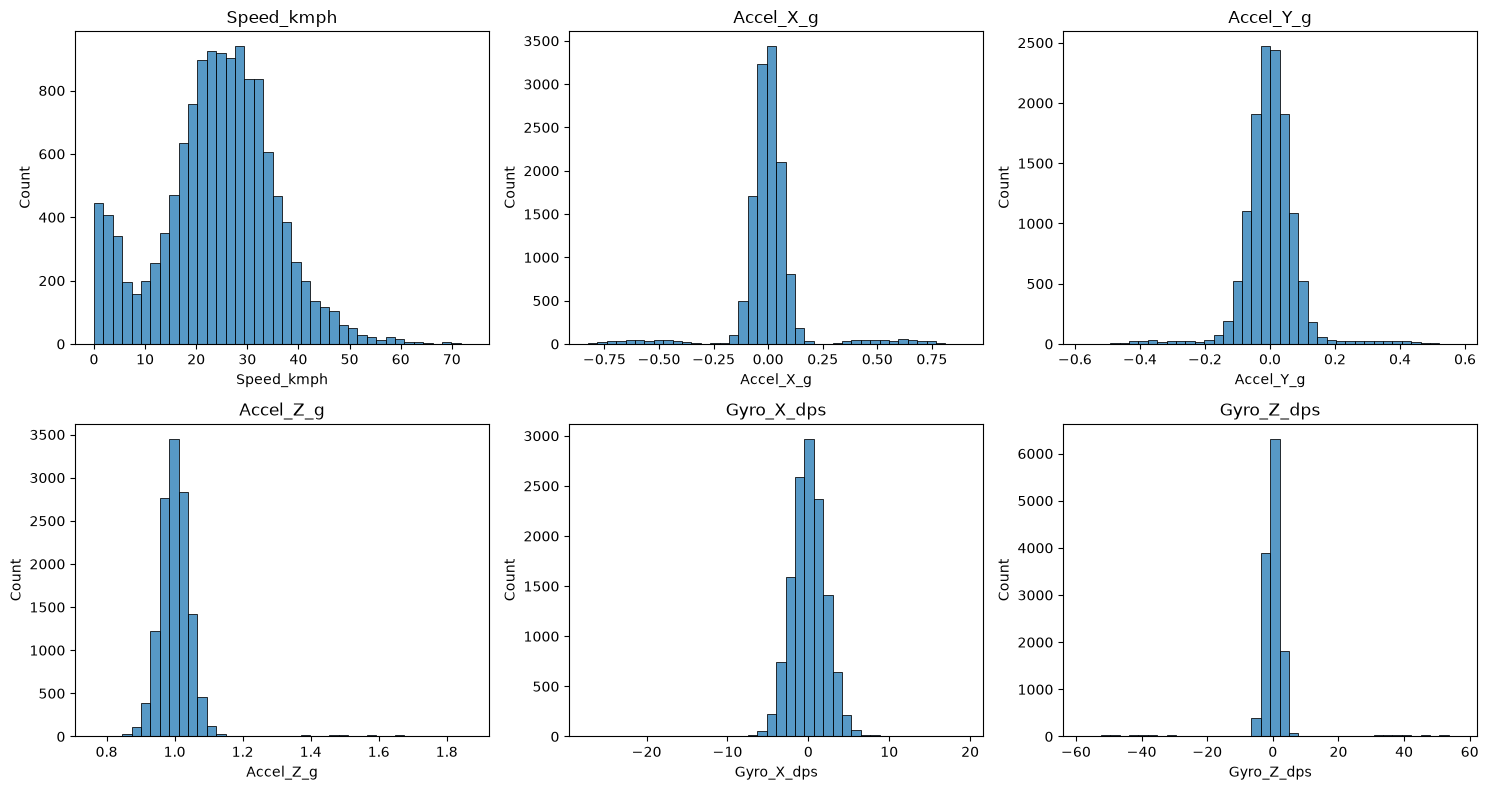

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
cols = ["Speed_kmph", "Accel_X_g", "Accel_Y_g", "Accel_Z_g", "Gyro_X_dps", "Gyro_Z_dps"]
for ax, col in zip(axes.flat, cols):
    sns.histplot(telemetry[col], bins=40, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

Telemetry distributions

Speed_kmph is bimodal — a smaller hump around 0-10 kmph and a dominant peak around 20-35 kmph. This isn't noise; it's almost certainly capturing two real driving states within trips — stopped/slow (traffic lights, junctions, crawling) vs cruising speed. So what: this means per-minute speed readings mix two different driving contexts, so if we build a "smoothness" feature later, we may want to treat near-zero speed readings separately (e.g. exclude or flag stopped segments) rather than averaging them in with cruising speed — otherwise a driver who hits more traffic looks artificially "inconsistent."

Accel_X_g, Accel_Y_g, Accel_Z_g, Gyro_X_dps, Gyro_Z_dps all show the same shape — a sharp, tall peak centered near baseline (0 for X/Y accel and gyro, ~1.0 for Accel_Z since that's gravity on the vertical axis), with a long, sparse, flat tail extending to the extremes. So what — this is the single most useful finding in the whole EDA: the vast majority of readings represent normal, steady driving (tight cluster near baseline), and the thin scattered tail is exactly where harsh-brake, harsh-accel, and harsh-cornering events live. This gives a data-driven justification for defining harsh-event thresholds statistically (e.g. beyond X standard deviations or a high percentile of the baseline cluster) rather than picking an arbitrary fixed g-value — the distribution itself is telling us where "normal" ends and "event" begins.

In [ ]:
print(drivers[["Age", "License_Experience_Years"]].describe())
print(vehicles["Manufacture_Year"].value_counts().sort_index())

             Age  License_Experience_Years
count  30.000000                 30.000000
mean   33.800000                  6.300000
std     5.523617                  4.153519
min    23.000000                  1.000000
25%    31.000000                  3.000000
50%    34.000000                  6.000000
75%    36.750000                  9.750000
max    44.000000                 14.000000
Manufacture_Year
2019    3
2020    4
2021    7
2022    3
2023    5
2024    3
2025    5
Name: count, dtype: int64


Driver and vehicle profiles

Drivers: ages range 23-44 (mean 33.8), license experience ranges 1-14 years (mean 6.3). Fairly experienced pool overall — no complete novices, but a meaningful spread exists (1 to 14 years), so experience could plausibly correlate with the eventual risk scores — worth checking as a validation step (does higher risk score trend with lower experience? If yes, that's a good sanity check that our scoring makes sense).

Vehicles: manufacture years span from at least 2019 onward — gives us fleet age as a potential vehicle-health covariate (older vehicles might show more wear-related anomalies, worth checking as one candidate hypothesis, not an assumption).

In [10]:
# Aggregate trip-level stats per driver — this becomes the skeleton
# for the driver risk score in Day 1's feature engineering step
driver_trip_summary = (
    trips.groupby("Driver_ID")
    .agg(
        total_trips=("Trip_ID", "count"),
        total_distance_km=("Distance_KM", "sum"),
        total_duration_min=("Duration_Min", "sum"),
        avg_speed_mean=("Avg_Speed_kmph", "mean"),
        max_speed_mean=("Max_Speed_kmph", "mean"),
        max_speed_overall=("Max_Speed_kmph", "max"),
    )
    .reset_index()
)

driver_trip_summary = driver_trip_summary.merge(drivers, on="Driver_ID")
driver_trip_summary.sort_values("max_speed_overall", ascending=False).head(10)

,Driver_ID,total_trips,total_distance_km,total_duration_min,avg_speed_mean,max_speed_mean,max_speed_overall,Driver_Name,Age,Gender,License_Experience_Years,Date_Joined_Fleet,Primary_Vehicle_ID,Home_Hub
5,D06,15,213.05,470,25.573333,55.893333,73.6,Bhavani Raj,34,Female,14,2024-12-01,V06,Electronic City
22,D23,15,197.79,457,24.720000,57.713333,70.2,Kavya Pillai,32,Male,11,2025-11-04,V23,Yeshwanthpur
23,D24,15,214.22,460,26.640000,55.246667,69.3,Lakshmi Iyer,32,Female,3,2025-02-19,V24,Bellandur
2,D03,15,200.36,482,22.853333,51.846667,68.8,Vignesh Murugan,35,Male,1,2024-02-28,V03,Bommanahalli
13,D14,15,164.23,426,25.426667,55.226667,65.5,Rajesh Subramaniam,31,Male,2,2026-04-09,V14,Rajajinagar
11,D12,15,168.85,360,24.820000,49.800000,64.5,Praveen Murugan,44,Female,7,2024-10-31,V12,HSR Layout
18,D19,15,136.31,338,24.573333,51.133333,63.3,Senthil Pillai,39,Male,1,2026-01-19,V19,Attibele
12,D13,15,201.62,431,24.293333,41.640000,61.8,Meena Kannan,39,Female,14,2025-11-16,V13,Electronic City
20,D21,15,201.79,472,24.826667,42.866667,59.5,Vignesh Raj,28,Male,13,2025-06-08,V21,MG Road
29,D30,15,239.92,474,22.366667,40.946667,58.0,Gokul Velu,26,Male,2,2025-03-06,V30,Bellandur


In [11]:
vehicle_trip_summary = (
    trips.groupby("Vehicle_ID")
    .agg(
        total_trips=("Trip_ID", "count"),
        total_distance_km=("Distance_KM", "sum"),
        avg_speed_mean=("Avg_Speed_kmph", "mean"),
        max_speed_overall=("Max_Speed_kmph", "max"),
    )
    .reset_index()
)

vehicle_trip_summary = vehicle_trip_summary.merge(vehicles, on="Vehicle_ID")
vehicle_trip_summary[
    [
        "Vehicle_ID",
        "total_trips",
        "total_distance_km",
        "Odometer_KM_Start_of_Week",
        "Last_Service_Date",
    ]
].sort_values("total_distance_km", ascending=False).head(10)

,Vehicle_ID,total_trips,total_distance_km,Odometer_KM_Start_of_Week,Last_Service_Date
8,V09,17,267.28,14294,2026-07-24
4,V05,15,258.60,2727,2026-07-12
22,V23,18,244.54,17821,2026-06-16
5,V06,16,237.18,3065,2026-07-18
14,V15,15,235.78,20041,2026-06-19
15,V16,15,231.92,22089,2026-06-30
16,V17,15,225.58,2639,2026-07-13
27,V28,16,221.82,17021,2026-06-23
6,V07,15,217.02,6030,2026-07-14
9,V10,16,215.13,30162,2026-07-01


In [12]:
driver_telemetry_summary = (
    telemetry.groupby("Driver_ID")
    .agg(
        accel_x_std=("Accel_X_g", "std"),
        accel_y_std=("Accel_Y_g", "std"),
        accel_x_max_abs=("Accel_X_g", lambda x: x.abs().max()),
        gyro_z_std=("Gyro_Z_dps", "std"),
        gyro_z_max_abs=("Gyro_Z_dps", lambda x: x.abs().max()),
        speed_mean=("Speed_kmph", "mean"),
    )
    .reset_index()
)

driver_telemetry_summary.sort_values("accel_x_max_abs", ascending=False).head(10)

,Driver_ID,accel_x_std,accel_y_std,accel_x_max_abs,gyro_z_std,gyro_z_max_abs,speed_mean
22,D23,0.222789,0.093049,0.898,10.247289,57.61,24.202407
29,D30,0.140093,0.074557,0.860,7.212878,55.93,21.997257
13,D14,0.243012,0.091032,0.844,9.574533,50.01,25.416432
19,D20,0.189500,0.084719,0.832,9.202550,55.54,24.689737
11,D12,0.201366,0.098195,0.832,10.144600,56.50,23.769722
23,D24,0.209839,0.103404,0.825,10.121969,55.42,26.602609
10,D11,0.091041,0.063790,0.823,5.466862,53.41,25.605322
18,D19,0.208315,0.107002,0.805,10.037489,52.62,24.631657
27,D28,0.097123,0.077551,0.803,6.462863,54.44,22.302250
16,D17,0.166815,0.085944,0.800,8.280467,53.70,25.614840


D23 stands out as consistently high across accel and gyro metrics simultaneously — the strongest candidate for a genuinely risky driver rather than a one-off event. Some drivers (e.g. D11) show high max values with lower std, suggesting isolated severe events rather than consistently rough driving — this distinction (consistency vs. one-off severity) should inform how the composite risk score is weighted later.

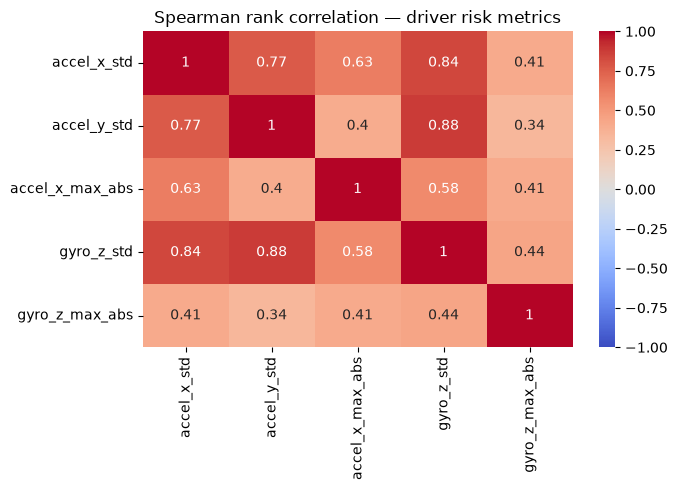

In [13]:
# Check whether drivers who rank high on one harsh-event metric
# also rank high on others — validates that this is real signal
# rather than metric-specific noise
corr_cols = [
    "accel_x_std",
    "accel_y_std",
    "accel_x_max_abs",
    "gyro_z_std",
    "gyro_z_max_abs",
]
corr_matrix = driver_telemetry_summary[corr_cols].corr(method="spearman")

plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Spearman rank correlation — driver risk metrics")
plt.tight_layout()
plt.show()

Rank correlation across risk metrics

Harsh-event metrics show moderate-to-strong positive Spearman correlation with each other:
- accel_x_std vs accel_y_std: 0.77, accel_x_std vs gyro_z_std: 0.84, accel_y_std vs gyro_z_std: 0.88 — strong agreement, confirming drivers who are rough on one linear/rotational axis tend to be rough on others.
- The `_max_abs` columns (accel_x_max_abs, gyro_z_max_abs) correlate more weakly with everything (0.34–0.63) — including with their own `_std` counterpart (accel_x_std vs accel_x_max_abs: 0.63).

So, the `_std` metrics (which capture overall consistency/roughness across a driver's whole telemetry history) form a tightly correlated cluster and likely represent one shared underlying "driving smoothness" signal — a composite risk score can probably lean on these together with confidence. The `_max_abs` metrics correlate more weakly, meaning they're capturing something more distinct — most likely single severe events rather than a driver's general tendency. This supports the earlier D11 observation: `_std` and `_max_abs` are measuring genuinely different things (consistent roughness vs isolated severe events), and the composite risk score in Day 2 should probably weight both separately rather than treating them as interchangeable.

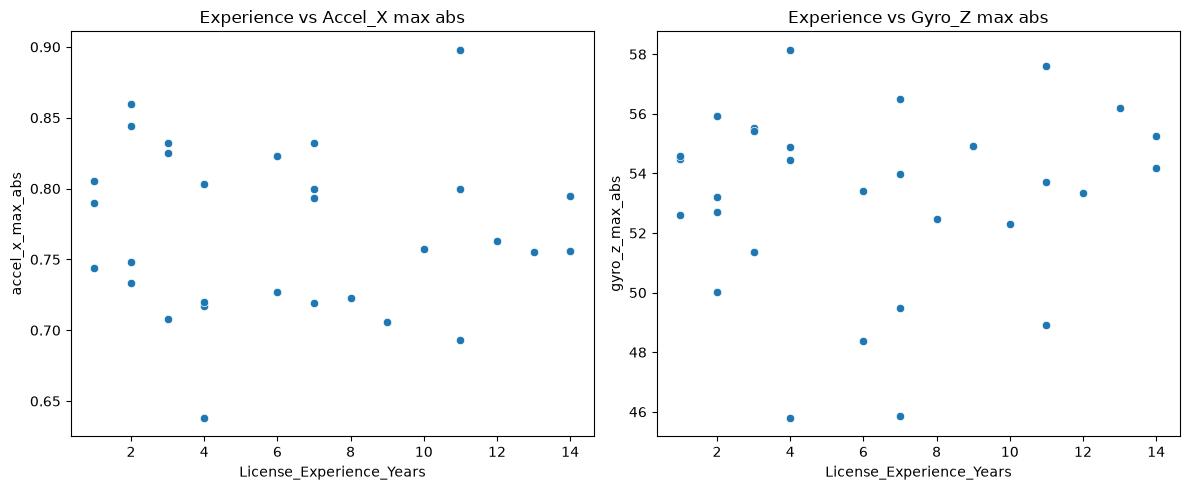

                          License_Experience_Years  accel_x_max_abs  \
License_Experience_Years                  1.000000        -0.110914   
accel_x_max_abs                          -0.110914         1.000000   
gyro_z_max_abs                            0.054997         0.411437   

                          gyro_z_max_abs  
License_Experience_Years        0.054997  
accel_x_max_abs                 0.411437  
gyro_z_max_abs                  1.000000  


In [14]:
# Merge telemetry-derived risk metrics with driver profile info
# to check whether rougher driving correlates with less experience —
# a sanity check that the signal reflects real driving behavior
driver_full = driver_telemetry_summary.merge(drivers, on="Driver_ID")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.scatterplot(
    data=driver_full, x="License_Experience_Years", y="accel_x_max_abs", ax=axes[0]
)
axes[0].set_title("Experience vs Accel_X max abs")

sns.scatterplot(
    data=driver_full, x="License_Experience_Years", y="gyro_z_max_abs", ax=axes[1]
)
axes[1].set_title("Experience vs Gyro_Z max abs")
plt.tight_layout()
plt.show()

print(
    driver_full[["License_Experience_Years", "accel_x_max_abs", "gyro_z_max_abs"]].corr(
        method="spearman"
    )
)

Experience vs risk metrics

Both scatterplots show no visible trend, and this is confirmed numerically: License_Experience_Years correlates with accel_x_max_abs at -0.11 and with gyro_z_max_abs at 0.05 — both close to zero, indicating no meaningful relationship in either direction.

So what: driving roughness in this dataset does not appear to be explained by license experience — an experienced driver (14 years) can show similar harsh-event values to a newer driver (1-2 years), and vice versa. This is a legitimate finding, not a failed check: it means experience isn't a useful proxy or confound for the risk score, and the composite score should be built purely from the telemetry-derived behavior metrics rather than adjusted for driver experience. Worth stating this explicitly in the final write-up as a validated assumption rather than an oversight.

In [16]:
# Roll telemetry up to vehicle level — preview of vehicle health features
vehicle_telemetry_summary = (
    telemetry.groupby("Vehicle_ID")
    .agg(
        accel_z_std=("Accel_Z_g", "std"),  # vertical vibration — key wear signal
        accel_z_mean=("Accel_Z_g", "mean"),
        gyro_x_std=("Gyro_X_dps", "std"),
        gyro_y_std=("Gyro_Y_dps", "std"),
        speed_mean=("Speed_kmph", "mean"),
    )
    .reset_index()
)

vehicle_telemetry_summary.sort_values("accel_z_std", ascending=False).head(10)

,Vehicle_ID,accel_z_std,accel_z_mean,gyro_x_std,gyro_y_std,speed_mean
1,V02,0.161740,1.033519,2.928843,3.263998,21.750339
18,V19,0.115462,1.018773,2.181280,2.682665,24.682888
12,V13,0.102199,1.009740,2.523328,2.184811,24.582367
24,V25,0.095159,1.013843,2.243622,2.444189,23.521185
22,V23,0.092630,1.010973,2.393588,2.244067,24.383243
25,V26,0.090229,1.010176,2.097477,2.221310,23.972527
9,V10,0.089735,1.012977,2.259938,2.297304,21.329424
14,V15,0.088997,1.003952,2.337386,2.363017,22.997495
23,V24,0.079925,1.007320,2.192031,2.019873,26.770192
0,V01,0.077026,1.007710,2.306438,2.082991,25.226464


Vehicle-level telemetry summary

V02, V19, and V13 show the highest vertical vibration (accel_z_std: 0.16, 0.12, 0.10), notably higher than the rest of the fleet, where most vehicles cluster below 0.09. accel_z_mean stays close to 1.0 for all vehicles as expected (gravity baseline), so accel_z_std — variability around that baseline — is the more informative wear signal, not the mean itself.

So what: this gives a clear top-of-list candidate set (V02, V19, V13) for the vehicle health dashboard's "needs attention" flag, pending validation against a real cause (age, service recency, or mileage) rather than treating the trip-week std alone as sufficient evidence of a fault.

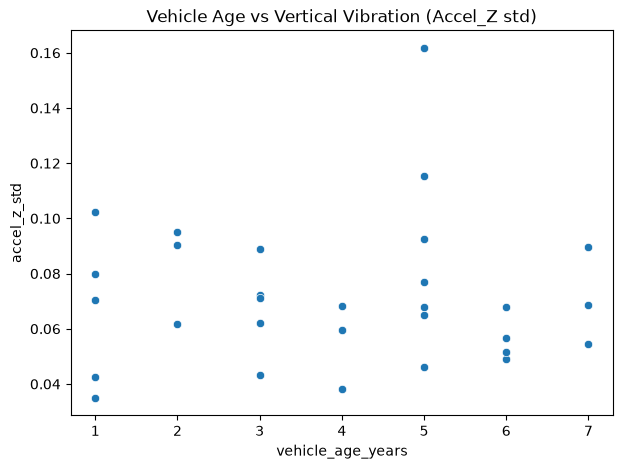

                   vehicle_age_years  accel_z_std
vehicle_age_years           1.000000    -0.066733
accel_z_std                -0.066733     1.000000


In [17]:
# Check whether older vehicles show more vibration noise —
# validates accel_z_std as a plausible wear indicator
vehicle_full = vehicle_telemetry_summary.merge(vehicles, on="Vehicle_ID")
vehicle_full["vehicle_age_years"] = 2026 - vehicle_full["Manufacture_Year"]

plt.figure(figsize=(7, 5))
sns.scatterplot(data=vehicle_full, x="vehicle_age_years", y="accel_z_std")
plt.title("Vehicle Age vs Vertical Vibration (Accel_Z std)")
plt.show()

print(vehicle_full[["vehicle_age_years", "accel_z_std"]].corr(method="spearman"))

Vehicle age vs vibration

No meaningful relationship — Spearman correlation is -0.067, essentially flat, and the scatter confirms it: high-vibration vehicles (like the one at 0.16) appear at age 5, while some age-1 and age-7 vehicles show similarly low vibration to each other.

So what: unlike expected, manufacture year alone isn't a useful predictor of vibration/wear in this fleet — consistent with real-world fleets where usage intensity and maintenance history matter more than calendar age. This means vehicle age shouldn't be weighted heavily in the health score; worth checking mileage and service recency instead (next cell).

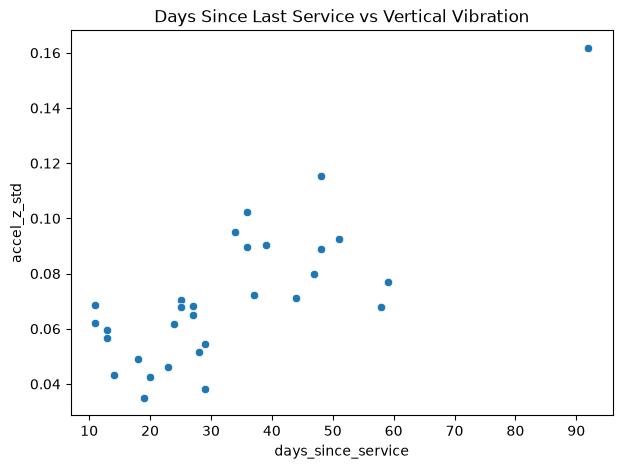

                    days_since_service  accel_z_std
days_since_service            1.000000     0.697317
accel_z_std                   0.697317     1.000000


In [18]:
vehicle_full["days_since_service"] = (
    pd.Timestamp("2026-08-06") - pd.to_datetime(vehicle_full["Last_Service_Date"])
).dt.days

plt.figure(figsize=(7, 5))
sns.scatterplot(data=vehicle_full, x="days_since_service", y="accel_z_std")
plt.title("Days Since Last Service vs Vertical Vibration")
plt.show()

print(vehicle_full[["days_since_service", "accel_z_std"]].corr(method="spearman"))

Days since last service vs vibration

Strong positive correlation: 0.70 (Spearman) — the clearest relationship found in the entire EDA. The scatter shows a fairly consistent upward trend: vehicles serviced more recently (10-20 days) cluster at low vibration (0.04-0.07), while vehicles further from their last service (35-60+ days) trend toward higher vibration (0.08-0.16), including the single highest-vibration vehicle at ~90 days since service.

So what: this is strong, validated evidence that days_since_service is a genuinely useful predictor of vehicle vibration/wear — much more useful than vehicle age. This should be a primary input to the vehicle health score in Day 2, likely more heavily weighted than age. It also supports a practical, explainable narrative for the dashboard: "vehicles overdue for service show measurably higher vibration," which is exactly the kind of finding a fleet manager could act on directly.

## EDA Summary

**Data quality:** Dataset is clean — no nulls, no duplicate IDs, no logical inconsistencies (avg speed never exceeds max, all telemetry rows map correctly to their parent trip).

**Trip-level patterns:** Duration and distance are fairly evenly spread rather than normally distributed; avg/max speed are right-skewed with a small set of higher-speed outlier trips.

**Telemetry signal shape:** Speed is bimodal (stopped/slow vs cruising). Accel and gyro axes show a tight baseline cluster with a sparse extreme tail — this tail is where harsh-event features will come from.

**Driver-side findings:**
- Harsh-event metrics correlate moderately-to-strongly with each other (0.4-0.88), suggesting a real underlying "driving smoothness" signal.
- `_std` (consistency) and `_max_abs` (severe one-off events) metrics correlate more weakly with each other — these represent different risk profiles and should be weighted separately in the composite score.
- License experience shows no correlation with harsh-event metrics (-0.11 to 0.05) — experience is not a useful proxy for risk in this dataset and won't be used to adjust the score.

**Vehicle-side findings:**
- Vertical vibration (Accel_Z std) is the clearest wear signal.
- Vehicle age shows no correlation with vibration (-0.07).
- **Days since last service shows a strong correlation with vibration (0.70)** — the single strongest relationship found in the EDA, and the primary candidate driver for the vehicle health score.

**Open assumption to carry forward:** avg speed may partly reflect route/context (e.g. Home_Hub) rather than pure driving style — flagged for awareness, not resolved here.